In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
path = "01314_SingleShotQND_AggronQA.h5"
with h5py.File(path, "r") as f:
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name}: shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"{name}/ (group)")
    f.visititems(show)

Pm1s: shape=(61, 4001, 2), dtype=float64
Ps: shape=(61, 4001, 2), dtype=float64
pulse_freq_list: shape=(4001,), dtype=float64
pulse_power_list: shape=(61,), dtype=float64


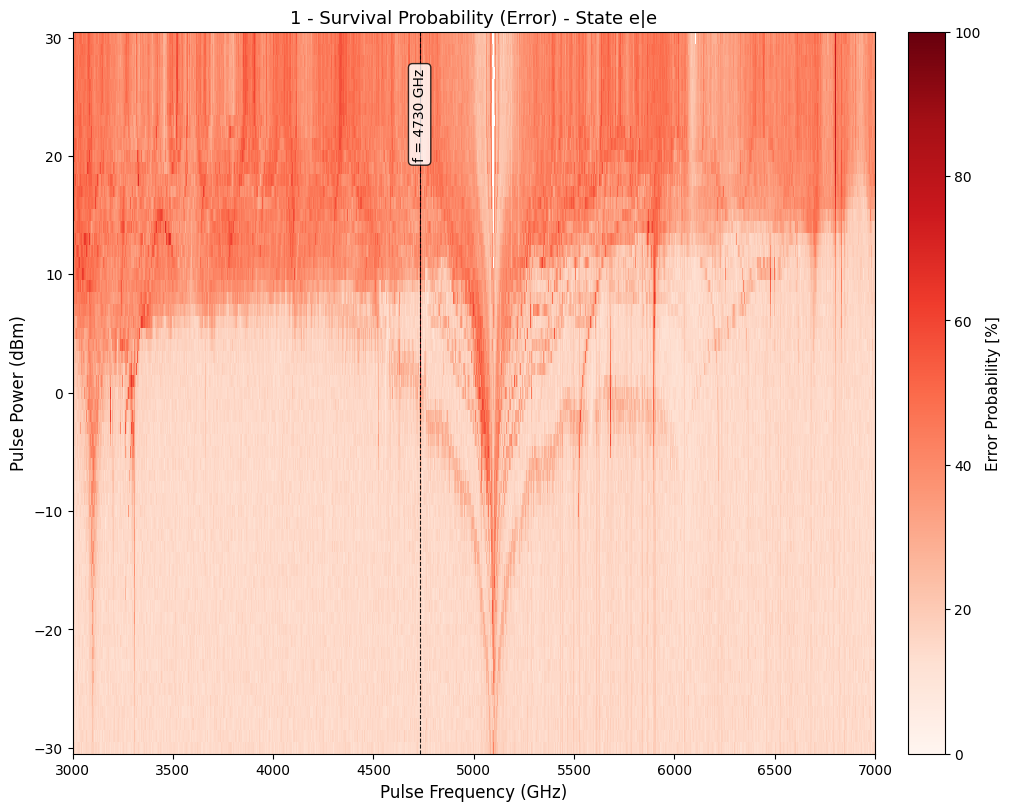

In [ ]:
from matplotlib.transforms import blended_transform_factory
from pathlib import Path
from datetime import datetime

def closest_index(arr, value):
    """Index of element in arr closest to value."""
    arr = np.asarray(arr)
    return int(np.abs(arr - value).argmin())

def exp_data_plot(state=0, target_freq_GHz=None, show_qnd=True, figsize=(10, 8)):
    with h5py.File(path, "r") as f:
        xdata = f['pulse_freq_list'][:]           
        ydata = f['pulse_power_list'][:]          
        zdata = f['Ps'][:]                       
        zdata2 = f['Pm1s'][:] if show_qnd else None  
    num_rows = 2 if show_qnd else 1
    fig, axes = plt.subplots(num_rows, 1, figsize=figsize, constrained_layout=True)
    if num_rows == 1:
        axes = np.array([axes]) 
    state_label = ["g|g", "e|e"][state]
    cmap = ['Blues', 'Reds'][state]
    zdata_plot = 100 - zdata[:, :, state]
    im1 = axes[0].pcolormesh(xdata, ydata, zdata_plot, 
                             shading='auto', cmap=cmap, vmin=0, vmax=100)
    axes[0].set_xlabel('Pulse Frequency (GHz)', fontsize=12)
    axes[0].set_ylabel('Pulse Power (dBm)', fontsize=12)
    axes[0].set_title(f'1 - Survival Probability (Error) - State {state_label}', fontsize=13)
    cbar1 = fig.colorbar(im1, ax=axes[0], pad=0.02)
    cbar1.set_label('Error Probability [%]', fontsize=11)
    if target_freq_GHz is not None:
        freq_idx = closest_index(xdata, target_freq_GHz)
        axes[0].axvline(target_freq_GHz, color='black', ls='--', lw=0.8, alpha=0.9)
        
        trans = blended_transform_factory(axes[0].transData, axes[0].transAxes)
        axes[0].text(target_freq_GHz, 0.95, f"f = {target_freq_GHz} GHz",
                    transform=trans, rotation=90, ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
                    zorder=5, fontsize=10)
    if show_qnd:
        zdata2_plot = 100 - zdata2[:, :, state]
        im2 = axes[1].pcolormesh(xdata, ydata, zdata2_plot, 
                                 shading='auto', cmap=cmap, vmin=0, vmax=100)
        axes[1].set_xlabel('Pulse Frequency (GHz)', fontsize=12)
        axes[1].set_ylabel('Pulse Power (dBm)', fontsize=12)
        axes[1].set_title(f'1 - QND Fidelity (Error) - State {state_label}', fontsize=13)
        cbar2 = fig.colorbar(im2, ax=axes[1], pad=0.02)
        cbar2.set_label('QND Error [%]', fontsize=11)
        if target_freq_GHz is not None:
            axes[1].axvline(target_freq_GHz, color='black', ls='--', lw=0.8, alpha=0.9)
            trans = blended_transform_factory(axes[1].transData, axes[1].transAxes)
            axes[1].text(target_freq_GHz, 0.95, f"f = {target_freq_GHz} GHz",
                        transform=trans, rotation=90, ha='center', va='top',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
                        zorder=5, fontsize=10)
    
    plt.show()
    
    return fig, axes


# exp_data_plot(state=0, target_freq_GHz=3082, show_qnd=True)
state = 1
# target_freq_GHz = 
target_freq_GHz = 4730
fig, axes = exp_data_plot(state=state, show_qnd=False, target_freq_GHz=target_freq_GHz)
dt = datetime.now().strftime("%m%d%Y")
savepath = Path(f"{dt}_qA_exp_data_plots")
savepath.mkdir(exist_ok=True)
# fig.savefig(savepath / f"state_{state}_target_{target_freq_GHz}.png", dpi=300, bbox_inches="tight")# exp_data_plot(state=0)

In [23]:
import datetime as dt
from pathlib import Path
today = dt.datetime.now().strftime("%m-%d-%Y")
savepath = Path(f"{today}_qA_exp_data_plots")
savepath.mkdir(parents=True, exist_ok=True)

In [47]:
# state = 0
# target_freq_GHz = 3082
fig.savefig(savepath / f"state_{state}_target_{target_freq_GHz}.png", dpi=300, bbox_inches="tight")# exp_data_plot(state=0)
